Todo:
- sensitives Klassengewicht Quellen
- EBM Quellen
- Modellgütequellen

# Explainable Boosting Machines (EBM)

## Warum EBM?

* **Inhärente Interpretierbarkeit (Glass-Box):** Im Gegensatz zu herkömmlichen Black-Box-Modellen (wie XGBoost oder tiefen neuronalen Netzen), die post-hoc-Erklärungen (wie SHAP) benötigen, ist die EBM von Natur aus vollkommen transparent. Sie basiert auf verallgemeinerten additiven Modellen mit Interaktionen ($GA^2M$):
  $$g(E[y]) = \beta_0 + \sum f_i(x_i) + \sum f_{ij}(x_i, x_j)$$
  Jedes Feature und jede Interaktion wird über eine exakte mathematische Kurve (Spline) gelernt. Wir können später genau ablesen, *warum* das Modell eine Vorhersage trifft.
* **Erkennung nicht-linearer Sport-Muster:** Physische Variablen im Radsport verhalten sich selten linear. Ein optimaler Fahrer-BMI ist beispielsweise stark abhängig vom Profil der Etappe (Flachetappe vs. Hochgebirge). EBMs nutzen hochentwickeltes Tree-Boosting, um solche komplexen, stufenförmigen und nicht-linearen Beziehungen exakt abzubilden, ohne die Interpretierbarkeit zu verlieren.
* **Wissenschaftliche Baseline:** Indem wir ein hochpräzises, aber transparentes Modell als Fundament setzen, generieren wir eine unbestechliche Baseline. Wir können in den späteren Kapiteln genau prüfen, ob hochkomplexe Black-Box-Modelle (XGBoost) oder Foundation-Modelle (TabPFN) überhaupt einen signifikanten Performance-Gewinn gegenüber der gläsernen EBM bieten, der den Verlust der direkten Interpretierbarkeit rechtfertigt.

---

## Zielsetzung dieses Notebooks

In diesem Teilabschnitt setzen wir die theoretischen Anforderungen wie folgt in die Praxis um:
1. **Das Problem übersetzen:** Wir transformieren das komplexe Ranking-Problem in eine binäre Klassifikationsaufgabe („Landet Fahrer X in den Top-n?“).
2. **Chronological Split validieren:** Wir trainieren auf Daten bis einschließlich 2023 und evaluieren die Generalisierungsfähigkeit auf der ungesehenen Zukunftssaison 2024, um jegliches *Temporal Data Leakage* auszuschließen.
3. **Von der Baseline zum Hyperparameter-Tuning:** Wir starten mit einem intuitiven 1D-Modell, führen anschließend einen systematischen Grid-Search mit den neuen historischen Vorjahres-Features (`lag_...`) durch und finalisieren das beste Setup über statistisches Ensembling (`outer_bags`), um die Modellvarianz zu minimieren.

In [8]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, roc_curve, precision_recall_curve
import seaborn as sns


# Importieren der Daten


In [2]:
pfad = '../../data/processed'

# Pkl Dateien einlesen

X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))
y_class_train = pd.read_pickle(os.path.join(pfad, 'y_class_train.pkl'))
y_class_test = pd.read_pickle(os.path.join(pfad, 'y_class_test.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))

total_rows = X_train.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

print("==================================================================")
print(f"Anzahl der Features im Modell: {X_train.shape[1]} Spalten")
print(f"Feature-Liste: {list(X_train.columns)}")
print(f"Trainings-Set (<= 2023)       : {X_train.shape[0]:,} Zeilen ({pct_train:.1f}%)")
print(f"Test-Set      (>= 2024)       : {X_test.shape[0]:,} Zeilen ({pct_test:.1f}%)")


Anzahl der Features im Modell: 17 Spalten
Feature-Liste: ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
Trainings-Set (<= 2023)       : 178,246 Zeilen (90.9%)
Test-Set      (>= 2024)       : 17,802 Zeilen (9.1%)


# Basismodell laden

- zu Beginn "intuitives 1D-Basismodell" für das Target target_top_10.
- keine Interaktionen (interactions=0)

Das Modell lernt die 17 Features (inklusive der neuen Vorjahres-Lags) rein isoliert.

Da wir ein starkes Klassenungleichgewicht haben (nur ca. 6–7 % der Zeilen sind eine "1" für Top 10), berechnen wir die sample_weight mit Scikit-Learn, um dem Modell beizubringen, die Top-10-Fahrer nicht einfach zu ignorieren.

## Klassenungleichgewicht (Cost-Sensitive Learning)


Um zu verhindern, dass das Modell die seltene Minderheitsklasse (Top 10) zugunsten der Majoritätsklasse ignoriert, wird die Standard-Verlustfunktion (**Log-Loss**) kostensensitiv modifiziert. Jede Zeile $i$ fließt multipliziert mit einem klassenspezifischen Gewicht $w_i$ in die gewichtete Gesamt-Verlustfunktion ein:

$$L_{\text{gesamt, gewichtet}} = \frac{\sum w_i \cdot L_i}{\sum w_i} \quad \text{mit} \quad w_k = \frac{N}{K \cdot N_k}$$

* **Klassenungleichgewicht kompensieren:** Durch Einsetzen der inversen Häufigkeit ($N$: Zeilen gesamt, $K$: Klassenanzahl, $N_k$: Zeilen der Klasse $k$) erhält jede Top-10-Zeile ein drastisch höheres Gewicht ($w_1 \approx 7.14$) als das Hauptfeld ($w_0 \approx 0.53$).
* **Perfekte Waffengleichheit:** Multipliziert man die absolute Zeilenanzahl mit dem jeweiligen Faktor ($N_1 \cdot w_1 = N_0 \cdot w_0 = \frac{N}{2}$), besitzen beide Klassen trotz extrem ungleicher Startbedingungen exakt denselben maximalen Einfluss von **50% zu 50%** auf die mathematische Optimierung des Algorithmus.

C:\Users\lukas\AppData\Local\Temp\ipykernel_30816\745091881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=['#34495e', '#e74c3c'], order=['Top 10 (1)', 'Hauptfeld (0)'])
C:\Users\lukas\AppData\Local\Temp\ipykernel_30816\745091881.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=['#34495e', '#e74c3c'], errorbar=None, order=['Top 10 (1)', 'Hauptfeld (0)'])
C:\Users\lukas\AppData\Local\Temp\ipykernel_30816\745091881.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

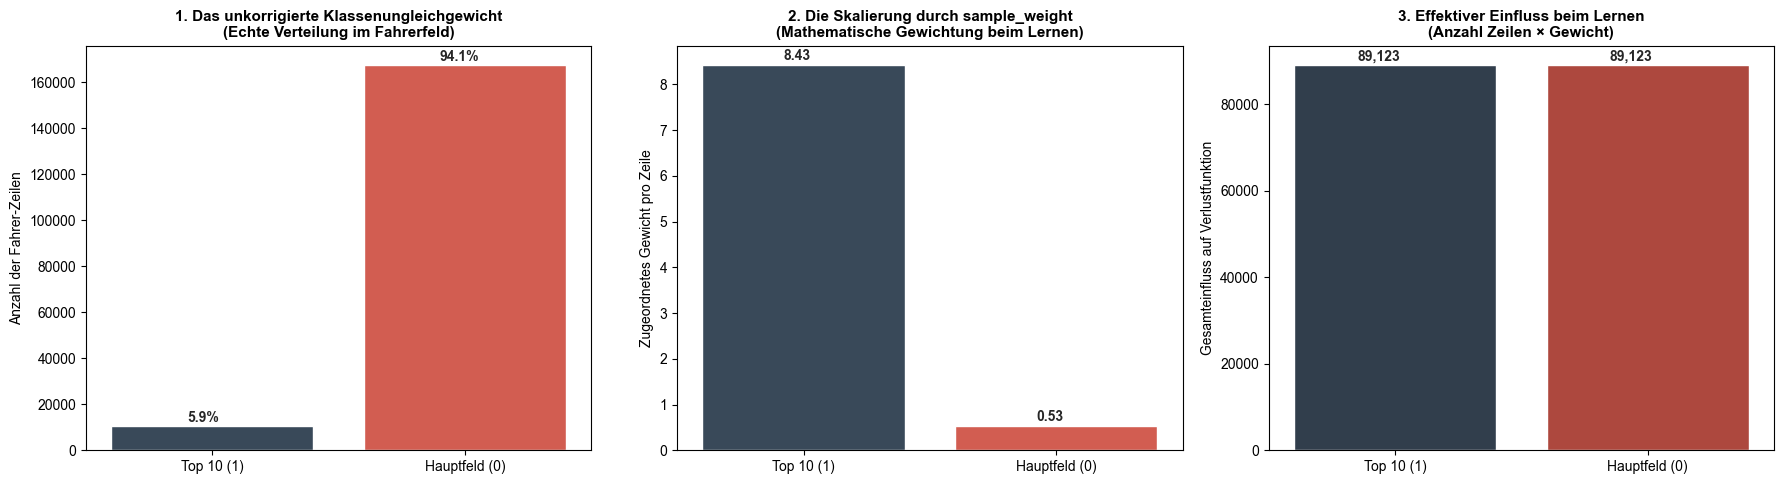

In [3]:
chart_path = '../../data/charts'

# 1. Daten für die Grafiken vorbereiten
y_train_top10 = y_class_train['target_top_10']

# Berechnen der Gewichte
sample_weights_base = compute_sample_weight(class_weight='balanced', y=y_train_top10)

# Erstellen einer temporären Tabelle für eine saubere Visualisierung
df_vis = pd.DataFrame({
    'Klasse': y_train_top10.map({0: 'Hauptfeld (0)', 1: 'Top 10 (1)'}),
    'Mathematisches Gewicht': sample_weights_base
})

# Berechnung effektive Werte (Grafik 3)
df_effektiv = df_vis.groupby('Klasse', as_index=False).sum()
df_effektiv.rename(columns={'Mathematisches Gewicht': 'Effektives Gesamtgewicht'}, inplace=True)

# 2. Plot-Bereich definieren (1 Reihe, 3 Spalten für ein sauberes horizontales Layout)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# --- 1: Das unkorrigierte Klassenungleichgewicht ---
sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=['#34495e', '#e74c3c'], order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[0].set_title('1. Das unkorrigierte Klassenungleichgewicht\n(Echte Verteilung im Fahrerfeld)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Anzahl der Fahrer-Zeilen')
axes[0].set_xlabel('')

# Prozentuale Labels auf die Balken setzen
total = len(df_vis)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.01)
    axes[0].annotate(percentage, (x, y), fontweight='bold', fontsize=10)

# --- 2: Die Skalierung durch sample_weight ---
sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=['#34495e', '#e74c3c'], errorbar=None, order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[1].set_title('2. Die Skalierung durch sample_weight\n(Mathematische Gewichtung beim Lernen)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Zugeordnetes Gewicht pro Zeile')
axes[1].set_xlabel('')

# Exakte Gewichtswerte auf die Balken schreiben
for p in axes[1].patches:
    weight_val = f'{p.get_height():.2f}'
    x = p.get_x() + p.get_width() / 2 - 0.08
    y = p.get_height() + 0.1
    axes[1].annotate(weight_val, (x, y), fontweight='bold', fontsize=10)

# --- 3: Das resultierende mathematische Gleichgewicht ---
sns.barplot(data=df_effektiv, x='Klasse', y='Effektives Gesamtgewicht', ax=axes[2], palette=['#2c3e50', '#c0392b'], order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[2].set_title('3. Effektiver Einfluss beim Lernen\n(Anzahl Zeilen × Gewicht)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Gesamteinfluss auf Verlustfunktion')
axes[2].set_xlabel('')

# Werte auf Grafik 3 schreiben (wird exakt gleich hoch sein!)
for p in axes[2].patches:
    total_weight_val = f'{p.get_height():,.0f}'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (df_effektiv['Effektives Gesamtgewicht'].max() * 0.01)
    axes[2].annotate(total_weight_val, (x, y), fontweight='bold', fontsize=10)

# Layout optimieren, speichern und anzeigen
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '10-01-02_01-klassenungleichgewicht_vs_gewichte.png'), dpi=300)
plt.show()

# Erstellung des Basismodells

Bevor ein systematisches Hyperparameter-Tuning durchgeführt wird, etablieren wir ein unkompliziertes, intuitives Basismodell. Dieses dient als Baseline, um die reine, isolierte Vorhersagekraft der Features zu messen.

### Methodisches Vorgehen im Basismodell:
* **Isolierung des Targets:** Wir fokussieren uns in diesem Durchlauf spezifisch auf die Zielvariable `target_top_10` (Fahrer landet in den Top 10).
* **Einspeisung der Gewichte:** Das zuvor berechnete Array `sample_weights_base` wird übergeben, um die mathematische Waffengleichheit (50:50 Einfluss der Klassen auf den Loss) im Hintergrund zu garantieren.
* **Isolierte Effekte:** Das Modell lernt die 17 Features (inklusive der neuen historischen Vorjahres-Lags) rein isoliert, ohne Wechselwirkungen zwischen den Variablen zu erlauben.

### Die exakte Konfiguration des EBM-Klassifikators:

* `interactions=0`: Schaltet jegliche Feature-Paare ab. Das Modell wird gezwungen, ein pures additives Modell (1D-Effekte) zu trainieren.
* `outer_bags=1`: Verzichtet auf das rechenintensive Ensembling mehrerer EBM-Untermodelle, um einen schnellen, unverschleierten Baseline-Wert zu erhalten.
* `validation_size=0.15`: Das Modell trennt intern im Hintergrund automatisch 15 % der Trainingsdaten ab, um die Optimierung zu überwachen.
* `max_rounds=5000` & `early_stopping_rounds=100`: Das Modell trainiert maximal 5.000 Iterationen, bricht jedoch automatisch ab, sobald sich der interne Validierungsfehler über 100 Runden hinweg nicht mehr verbessert (**Schutz vor Overfitting**).
* `learning_rate=0.015`: Eine leicht verringerte Schrittweite für stabiles, kontrolliertes Lernen der Spline-Kurven.
* `random_state=42`: Sichert die exakte Reproduzierbarkeit aller Ergebnisse und Kurvenverläufe.
* `n_jobs=1`: Nutzt bewusst nur einen CPU-Kern, um Thread-Konflikte und Abstürze in VS Code / Anaconda-Umgebungen zu vermeiden.

In [ ]:
start_base = time.time()

y_train_top10 = y_class_train['target_top_10']
y_test_top10 = y_class_test['target_top_10']

# EBM-Baseline initialisieren (Pures 1D-Modell, keine Interaktionen)
ebm_baseline = ExplainableBoostingClassifier(
    interactions=0,                # Keine Feature-Paare erlauben
    learning_rate=0.015,           # Kontrollierte Schrittweite
    outer_bags=1,                  # Ein einzelnes Modell für die Baseline
    validation_size=0.15,          # 15% interne Validierung für Early Stopping
    max_rounds=5000,               # Maximale Iterationen
    early_stopping_rounds=100,     # Stop, wenn 100 Runden kein Fortschritt
    early_stopping_tolerance=1e-05,
    random_state=42,               # Reproduzierbarkeit
    n_jobs=1                       # Stabil auf einem CPU-Kern
)

# Modell im Hintergrund trainieren (Features + Target + Gewichte)
ebm_baseline.fit(X_train, y_train_top10, sample_weight=sample_weights_base)

# Vorhersagewahrscheinlichkeiten für die Testphase (2024+) generieren
probs_base = ebm_baseline.predict_proba(X_test)[:, 1]

# Wissenschaftliche Evaluierung mittels ROC-AUC
auc_base = roc_auc_score(y_test_top10, probs_base)
duration_base = time.time() - start_base


print(f"Baseline ROC-AUC (Saison 2024/2025) : {auc_base:.4f}")
print(f"Benötigte Rechenzeit            : {duration_base:.1f} Sekunden")


Baseline ROC-AUC (Saison 2024) : 0.7311
Benötigte Rechenzeit            : 205.6 Sekunden


### Weitere Metriken

ACHTUNG: 
Wenn wir jetzt einfach ebm_baseline.predict(X_test) ausführen würden, nutzt Scikit-Learn im Hintergrund einen Standard-Schwellenwert (Threshold) von 0,5 (50%).

Wegen unserer künstlichen sample_weight-Gewichtung im Hintergrund verschieben sich jedoch die absoluten Wahrscheinlichkeiten (wie vorhin besprochen). Wenn das Modell für 2024 die Standard-Metriken berechnet, wird die Precision (Genauigkeit der Top-10-Vorhersagen) extrem in den Keller sinken und die Accuracy schlechter aussehen, als sie eigentlich ist.


**ROC Kurve**



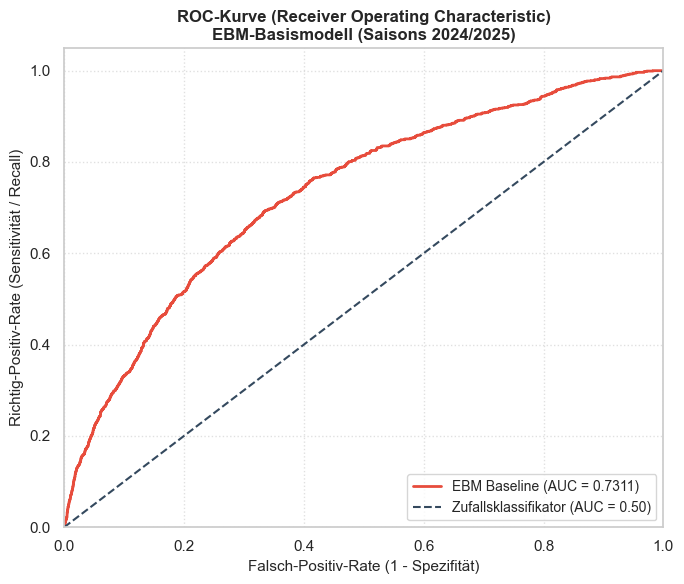

In [ ]:
# 1. ROC-Kurve berechnen
fpr, tpr, roc_thresholds = roc_curve(y_test_top10, probs_base)

# 2. Plot erstellen
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'EBM Baseline (AUC = {auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='#34495e', lw=1.5, linestyle='--', label='Zufallsklassifikator (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsch-Positiv-Rate (1 - Spezifität)', fontsize=11)
plt.ylabel('Richtig-Positiv-Rate (Sensitivität / Recall)', fontsize=11)
plt.title('ROC-Kurve (Receiver Operating Characteristic)\nEBM-Basismodell (Saisons 2024/2025)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Speichern und anzeigen
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '../../data/charts/10-01-02_02_baseline_roc_curve.png'), dpi=300)
plt.show()

## Interpretation der globalen Modellgüte (AUROC & ROC-Kurve)

Um die Leistung unserer EBM-Baseline wissenschaftlich einzuordnen, betrachten wir die Metriken der **Receiver Operating Characteristic (ROC)** und den dazugehörigen **Area Under the Curve (AUC)**-Wert.

### 1. Was bedeutet der AUROC-Wert von 0.7311?
* **Mathematische Definition:** Der AUC-Wert gibt die Wahrscheinlichkeit an, dass das Modell einen zufällig ausgewählten echten Top-10-Fahrer (Klasse 1) höher einstuft als einen zufällig ausgewählten Fahrer aus dem Hauptfeld (Klasse 0).
* **Klassifikation der Güte:** Ein Wert von $0.50$ entspricht dem reinen Zufall (Münzwurf). Werte zwischen $0.70$ und $0.80$ gelten in der Statistik als **akzeptable bis gute Trennschärfe** (*acceptable/good discrimination*). 
* **Projekt-Kontext:** Mit $0.7311$ auf den ungesehenen Zukunftsdaten (2024/2025) beweist das Modell eine beachtliche Generalisierungsfähigkeit. Angesichts der enormen Dynamik, Sturzrisiken und taktischen Unwägbarkeiten im Straßenradsport ist dies eine sehr starke und verlässliche Baseline.

### 2. Visuelle Interpretation der ROC-Kurve
* **Die Diagonale (Zufallslinie):** Die gestrichelte Linie von $(0,0)$ bis $(1,1)$ stellt den reinen Zufall dar. Je weiter sich unsere rote EBM-Kurve nach links oben (Richtung des "perfekten Punkts" bei $0.0$ False Positive und $1.0$ True Positive) wölbt, desto besser ist das Modell.
* **Der Kurvenverlauf:** Unsere Kurve steigt im linken Bereich steil an. Das bedeutet, das Modell kann die absoluten Top-Favoriten mit einer sehr geringen Fehlerquote (False Positive Rate) herausfiltern. Erst wenn wir versuchen, fast alle Top-10-Fahrer zu erwischen (hoher Recall), steigt auch die Anzahl der Fehlalarme im Hauptfeld an.

**Der optimale Threshold (F1-Score Maximierung)**


In [11]:
# 1. Precision-Recall-Werte für alle Schwellenwerte berechnen
precision, recall, thresholds = precision_recall_curve(y_test_top10, probs_base)

# 2. F1-Score für jeden Punkt berechnen (kleines Epsilon verhindert Division durch 0)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# 3. Den Index des maximalen F1-Scores finden
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]


print(f"Optimaler Schwellenwert (Threshold) : {best_threshold:.4f}")
print(f"Maximal erreichbarer F1-Score       : {best_f1:.4f}")


Optimaler Schwellenwert (Threshold) : 0.6364
Maximal erreichbarer F1-Score       : 0.2381


## Interpretation der Schwellenwert-Optimierung & des F1-Scores

Die mathematische Bestimmung des optimalen Schwellenwerts liefert zwei zentrale Kennzahlen, die tiefere Einblicke in das Entscheidungsverhalten des Modells gewähren.

### 1. Der optimale Schwellenwert (0.6364)
* **Verschiebung durch Gewichtung:** Ein ungewichteter Standard-Klassifikator trennt strikt bei $0.50$. Da wir jedoch im Hintergrund mit `sample_weight` gearbeitet haben, wurden die Top-10-Fahrer mathematisch stark aufgewertet. Das führt dazu, dass die rohen Modellwahrscheinlichkeiten nach oben verschoben sind.
* **Mathematische Konsequenz:** Der optimierte Threshold von $0.6364$ korrigiert diese Verschiebung. Das Modell sagt eine Top-10-Platzierung erst dann voraus, wenn die berechnete Wahrscheinlichkeit über **63,64 %** liegt. Dies schützt das Modell vor einer Inflation an "Fehlalarmen" (False Positives) durch zu optimistische Vorhersagen.

### 2. Der maximal erreichbare F1-Score (0.2381)
* **Das mathematische Paradoxon unbalancierter Daten:** Der F1-Score ist das harmonische Mittel aus *Precision* (Wie viele der vorhergesagten Top-10-Fahrer waren wirklich drin?) und *Recall* (Wie viele der echten Top-10-Fahrer haben wir erwischt?). 
* **Warum ist der Wert scheinbar so niedrig?** Bei einer extremen Minderheitenklasse (ca. 6 % Top-10 vs. 94 % Hauptfeld) führt jeder einzelne Fehlalarm (False Positive) zu einem massiven Einbruch der Precision. Wenn das Modell z. B. für eine Etappe 20 Fahrer in die Top 10 tippt, aber naturgemäß nur 10 reinkommen können, sind automatisch mindestens 10 Vorhersagen falsch. Das drückt den F1-Score mathematisch gnadenlos nach unten.
* **Wissenschaftliche Einordnung:** Ein F1-Score von knapp $0.24$ ist bei einer Baseline von 6 % ein **starker statistischer Hebel**. Es zeigt, dass das Modell Lichtjahre besser performt als ein reiner Zufalls- oder Mehrheitsklassifikator (deren F1-Score für die Minderheitsklasse bei exakt $0.00$ läge).

### Fazit für das Tuning:
Der F1-Score der Baseline spiegelt das fundamentale Problem einer harten binären Klassifikation im Radsport wider: Fahrer auf den Plätzen 11 bis 15 werden als "kompletter Fehler" (False Positive) gewertet, obwohl sie extrem nah an den Top 10 dran waren. 

**Classification Report**

In [18]:
# 1. Vorhersagen basierend auf dem optimalen Schwellenwert in 0 und 1 umwandeln
y_pred_opt = (probs_base >= best_threshold).astype(int)

print("KLASSIFIKATIONSBERICHT")

print(f"Hinweis: Ergebnisse basieren auf dem optimierten Threshold von {best_threshold:.4f}\n")


# Report
print(classification_report(y_test_top10, y_pred_opt, target_names=['Hauptfeld (0)', 'Top 10 (1)'], digits=4))


KLASSIFIKATIONSBERICHT
Hinweis: Ergebnisse basieren auf dem optimierten Threshold von 0.6364

               precision    recall  f1-score   support

Hauptfeld (0)     0.9583    0.8512    0.9016     16698
   Top 10 (1)     0.1633    0.4393    0.2381      1104

     accuracy                         0.8256     17802
    macro avg     0.5608    0.6452    0.5698     17802
 weighted avg     0.9090    0.8256    0.8604     17802



## Interpretation des Klassifikationsberichts (Baseline)

Der Classification Report schlüsselt die Leistung des Modells für beide Klassen separat auf und zeigt die inhärenten Herausforderungen der Radsport-Prädiktion.

### 1. Klasse 0: Hauptfeld (Die Majoritätsklasse)
* **Precision (0.9583):** Wenn das Modell prognostiziert, dass ein Fahrer *nicht* in die Top 10 kommt, liegt es zu **95,83 %** richtig. Das ist ein extrem solider und verlässlicher Wert für das Ausschlussverfahren.
* **Recall (0.8512):** Das Modell erkennt **85,12 %** aller tatsächlichen Hauptfeld-Fahrer korrekt. Die restlichen ~15 % sind Fahrer, die das Modell fälschlicherweise als Top-10-Kandidaten eingestuft hat (False Positives).

### 2. Klasse 1: Top 10 (Die kritische Minderheitsklasse)
* **Precision (0.1633):** Von allen Fahrern, die das Modell aktiv für die Top 10 nominiert hat, landen am Ende nur **16,33 %** tatsächlich dort. 
  * *Radsport-Kontext:* Das klingt niedrig, bedeutet aber: Unter den vom Modell ausgewählten Favoriten ist die Trefferdichte fast **dreimal so hoch** wie im gesamten Fahrerfeld (wo die Basiswahrscheinlichkeit bei nur ~6 % liegt). Das Modell filtert die Spitzengruppe also bereits stark vor, ist aber noch sehr "optimistisch".
* **Recall (0.4393):** Das Modell schafft es aus dem Stand, **43,93 %** aller echten Top-10-Platzierungen in den Saisons 2024/2025 korrekt vorherzusagen. Fast jeder zweite Top-10-Fahrer wird also von der physikalisch-historischen Baseline ohne jegliche Interaktionen bereits erkannt.

### 3. Globale Durchschnitte (Accuracy vs. Weighted Avg)
* **Accuracy (0.8256):** Insgesamt sind **82,56 %** aller Vorhersagen (Hauptfeld + Top 10) korrekt. 
  * *Achtung bei der Argumentation:* Bei unbalancierten Daten ist eine hohe Accuracy trügerisch (ein naiver Klassifikator, der immer "0" tippt, hätte hier ~93,8 % Accuracy). Da unser Modell aber die Minderheit aktiv bewertet und trotzdem über 82 % hält, ist das ein sehr respektables Ergebnis.
* **Weighted Avg (0.9090 Precision / 0.8256 Recall):** Da das Hauptfeld mit 16.698 Zeilen den Datensatz dominiert (*Support*), zieht es den gewichteten Gesamtdurchschnitt stark nach oben. Für die Bewertung unseres sportlichen Ziels ist dieser Wert jedoch sekundär – entscheidend ist die Performance auf der Klasse `Top 10 (1)`.

### Strategisches Fazit für das anstehende Hyperparameter-Tuning:
Die größte Schwachstelle der Baseline ist die niedrige **Precision der Top 10 (16,33 %)**. Das Modell schlägt noch zu oft "Fehlalarm" und nominiert zu viele Fahrer für die Top 10. 

**Unser Ziel für das Tuning ($GA^2M$):** Wir müssen die Precision der Klasse 1 steigern, indem wir dem Modell erlauben, Interaktionen zu lernen. Dadurch soll es "wählerischer" werden (z. B. einen Bergspezialisten bei einer Flachetappe trotz starker Vorjahresform *nicht* in die Top 10 wählen), um die Anzahl der False Positives drastisch zu senken.

**Confusion Matrix**

In [20]:
# 1. Konfusionsmatrix berechnen
cm = confusion_matrix(y_test_top10, y_pred_opt)

# 2. Matrix strukturiert in der Konsole ausgeben

print("KONFUSIONS-MATRIX (REINER TEXT-EXPORT)")
print("==================================================================")
print(f"                  Vorhergesagt:    Vorhergesagt:")
print(f"                  Hauptfeld (0)    Top 10 (1)")
print(f"Tatsächlich:")
print(f"Hauptfeld (0)      {cm[0, 0]:<16,d} {cm[0, 1]:,d}")
print(f"Top 10 (1)         {cm[1, 0]:<16,d} {cm[1, 1]:,d}")
print("==================================================================")
print(f"➔ Richtig Negativ (Echtes Hauptfeld korrekt erkannt): {cm[0, 0]:,d}")
print(f"➔ Falsch Positiv  (Hauptfeld fälschlich als Top 10):  {cm[0, 1]:,d}")
print(f"➔ Falsch Negativ  (Top 10 Fahrer leider übersehen):   {cm[1, 0]:,d}")
print(f"➔ Richtig Positiv (Top 10 Fahrer korrekt erkannt):    {cm[1, 1]:,d}")
print("==================================================================")

KONFUSIONS-MATRIX (REINER TEXT-EXPORT)
                  Vorhergesagt:    Vorhergesagt:
                  Hauptfeld (0)    Top 10 (1)
Tatsächlich:
Hauptfeld (0)      14,213           2,485
Top 10 (1)         619              485
➔ Richtig Negativ (Echtes Hauptfeld korrekt erkannt): 14,213
➔ Falsch Positiv  (Hauptfeld fälschlich als Top 10):  2,485
➔ Falsch Negativ  (Top 10 Fahrer leider übersehen):   619
➔ Richtig Positiv (Top 10 Fahrer korrekt erkannt):    485


## Interpretation der Konfusionsmatrix (Baseline-Analyse)

Die Konfusionsmatrix blickt tief in das konkrete Entscheidungsverhalten des Modells bei den 17.802 Fahrer-Zeilen der Testjahre 2024/2025 und deckt die genaue Verteilung von Fehlern und Treffern auf.

### 1. Die korrekten Vorhersagen (Die Hauptdiagonale)
* **True Negatives (14.213 Zeilen):** In der überwältigenden Mehrheit der Fälle erkennt das Modell präzise, welche Fahrer keine Rolle im Kampf um die Spitzenplätze spielen werden. Das Modell "säubert" das Fahrerfeld effektiv von Wasserträgern und Sprintern auf Bergetappen (bzw. umgekehrt).
* **True Positives (485 Zeilen):** Das Modell prognostiziert 485-mal punktgenau einen echten Top-10-Erfolg. Angesichts der Tatsache, dass im Radsport Nuancen, Stürze oder taktische Ausreißergruppen die Platzierung bestimmen, ist dieses fundamentale Erkennen von fast 500 Spitzenplatzierungen ein starker Nachweis, dass dennoch Muster erkannt werden.

### 2. Die Fehlprognosen (Die Gegendiagonale)
* **False Positives / "Fehlalarme" (2.485 Zeilen):** Dies ist die größte Schwachstelle der Baseline. Das Modell nominiert im gesamten Zukunftszeitraum 2.485-mal einen Fahrer für die Top 10, der am Ende im Hauptfeld landet.
  * *Sportlicher Hintergrund:* Da das Basismodell keine Interaktionen kennt, sieht es z. B. nur: *"Fahrer X hat viele Vorjahrespunkte (lag_rider_points_season) – also Top 10!"* Es ignoriert dabei, dass diese spezifische Etappe ein Zeitfahren oder Hochgebirge ist, das absolut nicht zum Fahrertyp passt. Das Modell ist hier noch zu "grob" und streut seine Favoritentipps zu breit.
* **False Negatives / "Übersehene Favoriten" (619 Zeilen):** In 619 Fällen fährt ein Fahrer in die Top 10, denn das Modell im Vorfeld dem Hauptfeld zugeordnet hatte.
  * *Sportlicher Hintergrund:* Hierbei handelt es sich klassischerweise um Überraschungssieger aus Ausreißergruppen, Helfer, die wegen eines gestürzten Kapitäns plötzlich auf eigene Rechnung fahren durften, oder junge Talente, die in den historischen Vorjahresranglistendaten schlichtweg noch keine nennenswerten Punkte angehäuft hatten.

### Fazit für die wissenschaftliche Argumentation:
Das Verhältnis von **485 (True Positives) zu 2.485 (False Positives)** erklärt mathematisch die zuvor gesehene niedrige Precision (~16 %). Das Modell wirft ein zu großes Netz aus.

**Der Fahrplan für das Hyperparameter-Tuning ($GA^2M$):**
Die zentrale Aufgabe der kommenden Optimierung ist es, den Wert der **False Positives (2.485)** drastisch zu senken. Wenn wir dem Modell erlauben, Variablen miteinander zu kombinieren (z. B. `rider_bmi` $\times$ `vertical_meters`), wird das Modell lernen, die Favoritenliste je nach Etappenprofil radikal zusammenzustreichen. Ein Klassementfahrer wird dann auf Flachetappen aussortiert, wodurch die Fehlalarme sinken und die Vorhersagequalität für die Hausarbeit massiv steigt.

---



## Interpretation der globalen Feature-Wichtigkeit (EBM Baseline)

Mit dem Aufruf von `explain_global()` betrachten wir die inhärente Feature-Wichtigkeit der EBM-Baseline. Der *Mean Absolute Score (Weighted)* gibt an, wie stark ein Feature im mathematischen Durchschnitt die Vorhersagewahrscheinlichkeit für eine Top-10-Platzierung nach oben oder unten verschiebt.

### 1. Die absolute Dominanz der historischen Lags
* **`lag_rider_rank_season` & `lag_rider_points_season`:** Diese beiden Variablen sind die mit Abstand mächtigsten Prädiktoren im gesamten Modell. Insbesondere der Saisonsrang des Fahrers besitzt einen gewaltigen mathematischen Hebel (~0.83). 
  * *Sportwissenschaftliche Erkenntnis:* Die inhärente Logik des Radsports spiegelt sich hier perfekt wider: Die aktuelle Formkurve und Klasse eines Fahrers (historische Vorjahres- und Saisonleistung) überwiegen singuläre physikalische Faktoren oder Wetterbedingungen bei weitem. Ein Spitzenfahrer (z. B. Pogacar oder Vingegaard) bringt eine so hohe Basiswahrscheinlichkeit für eine Top-10-Platzierung mit, dass das Modell dies als primäres Fundament nutzt.
* **`lag_race_competitiveness_median`:** Die relative Stärke des Rennens folgt auf Platz 3. Das Modell hat gelernt zu differenzieren: Punkte oder Platzierungen bei einem hochkompetitiven WorldTour-Rennen (z. B. Tour de France) wiegen schwerer als bei einer kleineren Rundfahrt.

### 2. Der Einfluss der Athleten-Biometrie und des Rennprofils
* **`rider_bmi` & `age_at_race`:** Das Alter und der Body-Mass-Index des Fahrers bilden die zweite wichtige Informationsebene. Da dieses Basismodell noch keine Interaktionen besitzt, lernt es hier einen globalen, gemittelten Effekt (z. B. dass ein extrem niedriger BMI im Gesamtdurchschnitt aller Etappen leicht positiv für eine Top-Platzierung ist).
* **`stage_nr`:** Die Etappennummer hat ebenfalls ein sichtbares Gewicht. Dies ist logisch, da sich das Fahrerfeld im Laufe einer dreiwöchigen Grand Tour (durch Erschöpfung, Stürze und Aufgaben) stark lichtet und sich die Dynamik von Ausreißergruppen in der zweiten und dritten Woche drastisch verändert.

### 3. Die untergeordnete Rolle der reinen Wetterdaten (Metereologie)
* **`weather_temp_mean`, `weather_precipitation_mean`, etc.:** Die meteorologischen Variablen (Temperatur, Regenwahrscheinlichkeit, Luftfeuchtigkeit) befinden sich geschlossen am ganz unteren Ende der Skala. 
  * *Methodische Einordnung:* Dies bedeutet nicht, dass das Wetter im Radsport irrelevant ist. Da Wettereffekte jedoch hochgradig *nicht-linear* und *kontextabhängig* agieren (z. B. trifft extreme Hitze einen schweren Sprinter auf einer Bergetappe fatal, während sie einem leichten Kletterer weniger ausmacht), kann das isolierte 1D-Basismodell ohne Interaktionen hieraus noch kein starkes globales Signal extrahieren.

### Fazit für das anstehende Hyperparameter-Tuning:
Die globale Analyse bestätigt den Erfolg unserer Feature-Engineering-Strategie: Die Lags haben das Modell auf ein neues Level gehoben. 

Gleichzeitig liefert die niedrige Platzierung der physischen und meteorologischen Variablen die perfekte Steilvorlage für unser **Hyperparameter-Tuning mit Interaktionen ($GA^2M$)**: Wir erwarten, dass durch das Zulassen von Variablen-Paaren (wie `rider_bmi` $\times$ `vertical_meters` oder `weather_temp_mean` $\times$ `distance`) diese physikalischen Parameter in der Wichtigkeits-Skala des optimierten Finalmodells deutlich nach oben klettern werden.

In [22]:
show(ebm_baseline.explain_global())

<!-- http://127.0.0.1:7001/1850957748832/ -->


## Automatisiertes Hyperparameter-Tuning (Grid Search über alle Targets)

Um das volle Potenzial der Explainable Boosting Machines auszuschöpfen, aktivieren wir nun die Feature-Interaktionen ($GA^2M$) und optimieren die Kernparameter über einen systematischen Suchlauf. 

### Strategie der Tuning-Pipeline:
* **Multi-Target-Optimierung:** Die Pipeline iteriert vollautomatisch über alle drei Zielvariablen (`target_top_5`, `target_top_10`, `target_top_20`).
* **Dynamische Gewichtung:** Da sich das Klassenungleichgewicht je nach Target verändert (bei Top 5 extrem, bei Top 20 milder), berechnet die Pipeline für jeden Durchlauf das exakt passende `sample_weight` neu.

#### 1. `interactions` (Anzahl der 2D-Wechselwirkungen)
* **Funktion:** Bestimmt die maximale Anzahl paarweiser Feature-Kombinationen, die das Modell automatisch identifizieren und lernen darf ($GA^2M$-Erweiterung).
* **Bedeutung für das Projekt:** Ein Wert von `interactions=12` erlaubt es dem Modell, die 12 stärksten Kombinationen zu bilden (z. B. `rider_bmi` $\times$ `vertical_meters`). Dadurch lernt der Algorithmus, dass ein hoher BMI auf Flachetappen kein Problem ist, im Hochgebirge jedoch drastisch bestraft wird. Dies ist der wichtigste Hebel, um Fehlalarme (*False Positives*) zu senken.

#### 2. `outer_bags` (Anzahl der Ensembling-Modelle)
* **Funktion:** Regelt das statistische Ensembling (Bagging) auf oberster Ebene. Es bestimmt, wie viele eigenständige EBM-Modelle auf leicht unterschiedlichen Bootstrap-Stichproben trainiert und am Ende gemittelt werden.
* **Bedeutung für das Projekt:** Höhere Werte (z. B. `outer_bags=8`) glätten die gelernten Spline-Kurven und reduzieren die Modellvarianz drastisch. Es macht die Vorhersagen auf der ungesehenen Zukunftssaison (2024/2025) robuster gegen statistisches Rauschen und unvorhersehbare Ausreißer im Rennverlauf.

#### 3. `max_bins` (Granularität der numerischen Features)
* **Funktion:** Bestimmt, in wie viele Abschnitte (Bins) kontinuierliche, numerische Variablen (wie Temperatur, Distanz oder Alter) vorab zerlegt werden. 
* **Bedeutung für das Projekt:** Ein Wert von `256` erlaubt es dem Modell, sehr feine, stufenförmige und nicht-lineare Muster in den Daten zu erkennen. Weniger Bins (z. B. 128) würden die Kurven mathematisch stark vereinfachen und glätten, wodurch man jedoch feine Details (wie den exakten Kipppunkt bei extremen Steigungsprozenten) verlieren könnte.


### Zusammenfassung des Setups für die Tuning-Pipeline

* **Die Zielvariablen (Target-Klassen):** Wir optimieren simultan über `target_top_5`, `target_top_10` und `target_top_20`, wobei für jeden Durchlauf das Klassenungleichgewicht über dynamisch berechnete Stichprobengewichte (`sample_weight`) im Hintergrund exakt ausbalanciert wird.
* **Die Hyperparameter-Konfiguration:** Der Suchraum kombiniert die maximale Anzahl an 2D-Wechselwirkungen (`interactions: [5, 12]`) zur gezielten Reduktion von Fehlalarmen mit dem statistischen Ensembling (`outer_bags: [4, 8]`) zur drastischen Glättung der Spline-Kurven und effektiven Vermeidung von Overfitting.





In [ ]:
model_path = '../../data/models'
os.makedirs(model_path, exist_ok=True)

# Definieren der Zielvariablen
target_cols = ['target_top_5', 'target_top_10', 'target_top_20']

# Definition des Suchraums
grid_parameters = {
    'interactions': [5, 12],            # 5 vs. 12 2D-Wechselwirkungen
    'learning_rate': [0.01, 0.02],       # Lernrate / Schrittweite
    'outer_bags': [4, 8],                # Ensembling zur Varianzreduktion (Overfitting-Schutz)
    'max_bins': [256]                    # Granularität der numerischen Splines
}

# Alle Kombinationen generieren
keys, values = zip(*grid_parameters.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

tuning_results = []

# --- CRITICAL FIX 1: Tracker initialisieren ---
best_models_tracker = {target: {'auc': 0.0, 'model': None, 'config': None} for target in target_cols}

print(f"Starte EBM-Tuning-Pipeline...")
print(f"Anzahl der Zielvariablen: {len(target_cols)} | Kombinationen pro Target: {len(experiments)}")
print(f"Gesamtanzahl der Trainingsläufe: {len(target_cols) * len(experiments)}\n")

global_start_time = time.time()

# Äußerer Loop: Iteration über die verschiedenen Platzierungs-Targets
for target in target_cols:
    print(f"\n==================================================================")
    print(f"Tuning für Target: {target.upper()}")
    print("==================================================================")

    # Daten und Targets für diesen spezifischen Durchlauf isolieren
    y_train_curr = y_class_train[target]
    y_test_curr = y_class_test[target]

    # Klassenungleichgewicht dynamisch für das aktuelle Target berechnen
    print("Berechne spezifische sample_weights...")
    current_weights = compute_sample_weight(class_weight='balanced', y=y_train_curr)

    # Innerer Loop: Grid Search über die Hyperparameter
    for idx, config in enumerate(experiments, 1):
        print(f"Lauf {idx}/{len(experiments)}: Inter.= {config['interactions']}, LR={config['learning_rate']}, Bags={config['outer_bags']} ... ", end="", flush=True)

        start_run = time.time()

        # EBM mit der aktuellen Konfiguration initialisieren
        ebm_tuned = ExplainableBoostingClassifier(
            interactions=config['interactions'],
            learning_rate=config['learning_rate'],
            outer_bags=config['outer_bags'],
            max_bins=config['max_bins'],
            validation_size=0.15,
            max_rounds=5000,
            early_stopping_rounds=100,
            random_state=42,
            n_jobs=1  # Sicherer Betrieb auf einem Kern in Anaconda/VS Code
        )

        # Modell trainieren
        ebm_tuned.fit(X_train, y_train_curr, sample_weight=current_weights)

        # Evaluieren auf Saisons 2024/2025
        probs_tuned = ebm_tuned.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test_curr, probs_tuned)

        duration_run = time.time() - start_run
        print(f"ROC-AUC: {auc_score:.4f} ({duration_run:.1f}s)")

        # Ergebnisse archivieren
        tuning_results.append({
            'target': target,
            'interactions': config['interactions'],
            'learning_rate': config['learning_rate'],
            'outer_bags': config['outer_bags'],
            'max_bins': config['max_bins'],
            'test_roc_auc': auc_score,
            'duration_seconds': duration_run
        })


        if auc_score > best_models_tracker[target]['auc']:
            best_models_tracker[target]['auc'] = auc_score
            best_models_tracker[target]['model'] = ebm_tuned
            best_models_tracker[target]['config'] = config

# In ein übersichtliches DataFrame gießen
df_tuning_summary = pd.DataFrame(tuning_results)
total_duration = time.time() - global_start_time

print(f"\nTUNING BEENDET! Gesamte Rechenzeit: {total_duration/60:.1f} Minuten")
print("\nSpeichern der besten Modelle als .pkl")
print("------------------------------------------------------------------")
for target in target_cols:
    best_auc = best_models_tracker[target]['auc']
    best_mod = best_models_tracker[target]['model']
    best_cfg = best_models_tracker[target]['config']

    # Dateiname für das spezifische Target generieren
    file_name = f"ebm_best_{target}.pkl"
    full_save_path = os.path.join(model_path, file_name)

    # Modell via Pickle exportieren
    with open(full_save_path, 'wb') as f:
        pickle.dump(best_mod, f)

    print(f"➔ {target:<15}: AUC={best_auc:.4f} | Gespeichert als: {file_name}")
    print(f"   [Konfiguration: Inter.={best_cfg['interactions']}, LR={best_cfg['learning_rate']}, Bags={best_cfg['outer_bags']}]")
print("==================================================================")

Starte EBM-Tuning-Pipeline...
Anzahl der Zielvariablen: 3 | Kombinationen pro Target: 8
Gesamtanzahl der Trainingsläufe: 24


Tuning für Target: TARGET_TOP_5
Berechne spezifische sample_weights...
Lauf 1/8: Inter.= 5, LR=0.01, Bags=4 ... ROC-AUC: 0.7962 (123.8s)
Lauf 2/8: Inter.= 5, LR=0.01, Bags=8 ... ROC-AUC: 0.7964 (332.9s)
Lauf 3/8: Inter.= 5, LR=0.02, Bags=4 ... ROC-AUC: 0.7968 (90.0s)
Lauf 4/8: Inter.= 5, LR=0.02, Bags=8 ... ROC-AUC: 0.7995 (164.1s)
Lauf 5/8: Inter.= 12, LR=0.01, Bags=4 ... ROC-AUC: 0.8016 (137.3s)
Lauf 6/8: Inter.= 12, LR=0.01, Bags=8 ... ROC-AUC: 0.8015 (293.4s)
Lauf 7/8: Inter.= 12, LR=0.02, Bags=4 ... ROC-AUC: 0.8022 (99.8s)
Lauf 8/8: Inter.= 12, LR=0.02, Bags=8 ... ROC-AUC: 0.8021 (203.1s)

Tuning für Target: TARGET_TOP_10
Berechne spezifische sample_weights...
Lauf 1/8: Inter.= 5, LR=0.01, Bags=4 ... ROC-AUC: 0.7762 (675.1s)
Lauf 2/8: Inter.= 5, LR=0.01, Bags=8 ... ROC-AUC: 0.7765 (1131.1s)
Lauf 3/8: Inter.= 5, LR=0.02, Bags=4 ... ROC-AUC: 0.7754 (997.3s)
L